In [1]:
from forget.model import Llama2Wrapper, Llama3Wrapper
from forget.chat import Chat
import torch as t
import os
import pandas as pd
import re
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

HF_TOKEN = os.getenv("HF_TOKEN")

In [2]:
# llm = Llama2Wrapper(hf_token=HF_TOKEN, size="7b", use_chat=True, gpu_id=0)
llm = Llama3Wrapper(hf_token=HF_TOKEN, size="8b", use_chat=True, gpu_id=0)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [3]:
# chat = Chat(system_prompt="You are a helpful assistant.")
# chat.add_user_message("What is the capital of France?")
# response = llm.generate_from_chat(chat, max_new_tokens=100)
# print(response)

In [2]:
df_good = pd.read_csv("store/tofu/good.csv")
df_bad = pd.read_csv("store/tofu/bad.csv")

first_author = df_good["author"].unique()[0]
first_author

'Maria Garcia Alvarez'

# run baseline benchmark

In [ ]:
MCQ_SYSTEM = "You are answering multiple choice questions. Reply with ONLY the letter of the correct answer (A, B, C, or D). Do not explain."

ASSISTANT_HEADER = "<|start_header_id|>assistant<|end_header_id|>"

def trim_to_assistant(raw: str) -> str:
    idx = raw.rfind(ASSISTANT_HEADER)
    return raw[idx + len(ASSISTANT_HEADER):].strip() if idx != -1 else raw.strip()

def format_mcq_prompt(row):
    return (
        f"{row['question']}\n"
        f"A) {row['A']}\n"
        f"B) {row['B']}\n"
        f"C) {row['C']}\n"
        f"D) {row['D']}"
    )

def parse_answer(response: str) -> str:
    idx = response.rfind(ASSISTANT_HEADER)
    tail = response[idx + len(ASSISTANT_HEADER):] if idx != -1 else response
    match = re.search(r'\b([ABCD])\b', tail)
    return match.group(1) if match else ""

def evaluate_row(llm, row):
    chat = Chat(system_prompt=MCQ_SYSTEM)
    chat.add_user_message(format_mcq_prompt(row))
    raw = llm.generate_from_chat(chat, max_new_tokens=10, do_sample=False, temperature=1.0)
    parsed = parse_answer(raw)
    correct = int(parsed == row["answer"])
    return raw, parsed, correct

def acc_by_author(df, author):
    mask = df["author"] == author
    return df.loc[mask, "correct"].mean(), df.loc[~mask, "correct"].mean()

def empty_rate_by_author(df, author):
    mask = df["author"] == author
    return (df.loc[mask, "parsed"] == "").mean(), (df.loc[~mask, "parsed"] == "").mean()

In [6]:
rows = []
pbar = tqdm(df_good.iterrows(), total=len(df_good))
for i, row in pbar:
    raw, parsed, correct = evaluate_row(llm, row)
    rows.append({
        "author": row["author"],
        "question": row["question"],
        "scale": 0.0,
        "layer": -1,
        "model_output": trim_to_assistant(raw),
        "parsed": parsed,
        "actual": row["answer"],
        "correct": correct,
    })
    acc = sum(r["correct"] for r in rows) / len(rows)
    pbar.set_description(f"acc: {acc:.1%}")

baseline_df = pd.DataFrame(rows)
baseline_df.to_csv("store/llama3/baseline.csv", index=False)

  0%|          | 0/100 [00:00<?, ?it/s]

In [7]:
a_acc, o_acc = acc_by_author(baseline_df, first_author)
a_empty, o_empty = empty_rate_by_author(baseline_df, first_author)
print(f"Baseline — {first_author}: acc={a_acc:.1%}, empty={a_empty:.1%}")
print(f"Baseline — others: acc={o_acc:.1%}, empty={o_empty:.1%}")

Baseline — Maria Garcia Alvarez: acc=100.0%, empty=0.0%
Baseline — others: acc=97.5%, empty=0.0%


# calculate steering vector

In [16]:

def extract_activations(llm, chat):
    llm.reset_all()
    llm.forward_from_chat(chat)
    num_layers = len(llm.model.model.layers)
    layer_acts = []
    for i in range(num_layers):
        act = llm.get_last_activations(i).detach().cpu()
        if act.dim() == 2:
            act = act.unsqueeze(0)
        layer_acts.append(act[:, -1, :])
    return t.stack(layer_acts)  # (num_layers, 1, hidden_dim)

def collect_activations(llm, df, system_prompt=MCQ_SYSTEM):
    all_acts = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="collecting activations"):
        chat = Chat(system_prompt=system_prompt)
        chat.add_user_message(format_mcq_prompt(row))
        chat.add_assistant_message(row["answer"])
        acts = extract_activations(llm, chat)
        all_acts.append(acts)
    return t.stack(all_acts)  # (n_samples, num_layers, 1, hidden_dim)


In [23]:
chat = Chat(system_prompt=MCQ_SYSTEM)
# chat.add_user_message(format_mcq_prompt(df_good_a1[0]))
chat

Chat with 1 messages
System: You are answering multiple choice questions. Reply with ONLY the letter of the correct answer (A, B, C, or D). Do not explain.

In [9]:

df_good_a1 = df_good[df_good["author"] == first_author]
df_bad_a1 = df_bad[df_bad["author"] == first_author]
print(f"Author: {first_author} — {len(df_good_a1)} good, {len(df_bad_a1)} bad")


Author: Maria Garcia Alvarez — 20 good, 20 bad


In [10]:
good_acts = collect_activations(llm, df_good_a1)
bad_acts = collect_activations(llm, df_bad_a1)

t.save(good_acts, "store/llama3/good.pt")
t.save(bad_acts, "store/llama3/bad.pt")
print(f"good: {good_acts.shape}, bad: {bad_acts.shape}")


collecting activations:   0%|          | 0/20 [00:00<?, ?it/s]

collecting activations:   0%|          | 0/20 [00:00<?, ?it/s]

good: torch.Size([20, 32, 1, 4096]), bad: torch.Size([20, 32, 1, 4096])


# run steered benchmark

In [11]:
good_acts = t.load("store/llama3/good.pt")
bad_acts = t.load("store/llama3/bad.pt")

steer = (bad_acts - good_acts).mean(dim=0)  # (num_layers, 1, hidden_dim)
steer = steer.to(llm.device)
print(steer.shape)

torch.Size([32, 1, 4096])


In [12]:
def evaluate_steered(llm, df, steer_vec, layer=12, scale=4.0):
    rows = []
    pbar = tqdm(df.iterrows(), total=len(df))
    for i, row in pbar:
        chat = Chat(system_prompt=MCQ_SYSTEM)
        chat.add_user_message(format_mcq_prompt(row))

        llm.reset_all()
        llm.set_add_activations(layer, scale * steer_vec[layer])
        raw = llm.generate_from_chat(chat, max_new_tokens=10, do_sample=False, temperature=1.0)
        llm.reset_all()

        parsed = parse_answer(raw)
        correct = int(parsed == row["answer"])
        rows.append({
            "author": row["author"],
            "question": row["question"],
            "scale": scale,
            "layer": layer,
            "model_output": trim_to_assistant(raw),
            "parsed": parsed,
            "actual": row["answer"],
            "correct": correct,
        })
        acc = sum(r["correct"] for r in rows) / len(rows)
        pbar.set_description(f"acc: {acc:.1%}")
    return pd.DataFrame(rows)

In [13]:
scales = [0, 1, 2, 4, 6, 8, 12, 16, 18, 20, 22, 24, 26, 30, 32, 36, 40, 48, 56, 64, 128]
all_dfs = []
for s in scales:
    sdf = evaluate_steered(llm, df_good, steer_vec=steer, layer=12, scale=s)
    all_dfs.append(sdf)

steered_df = pd.concat(all_dfs, ignore_index=True)
steered_df.to_csv("store/llama3/steered.csv", index=False)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

# Plots

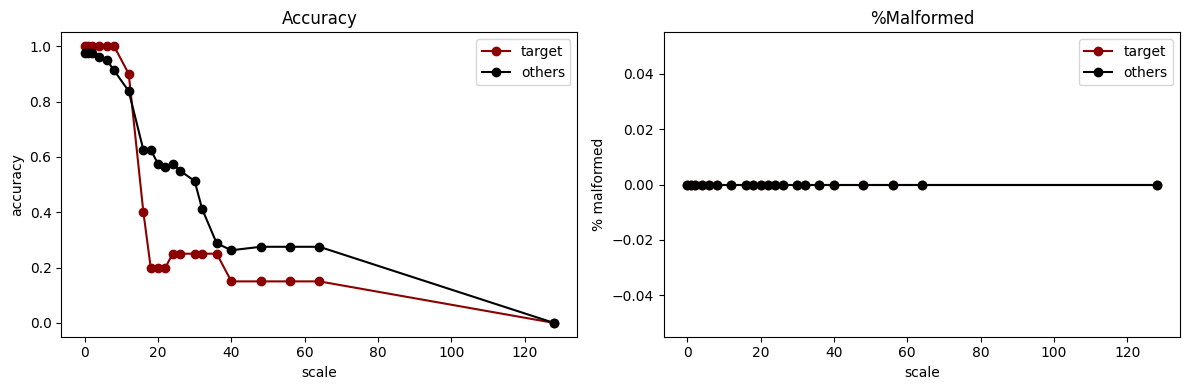

In [14]:
steered_df = pd.read_csv("store/llama3/steered.csv")

scales = sorted(steered_df["scale"].unique())
a_accs, o_accs, a_empties, o_empties = [], [], [], []
for s in scales:
    sub = steered_df[steered_df["scale"] == s]
    a_acc, o_acc = acc_by_author(sub, first_author)
    a_empty, o_empty = empty_rate_by_author(sub, first_author)
    a_accs.append(a_acc)
    o_accs.append(o_acc)
    a_empties.append(a_empty)
    o_empties.append(o_empty)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(scales, a_accs, color="darkred", marker="o", label="target")
ax1.plot(scales, o_accs, color="black", marker="o", label="others")
ax1.set_xlabel("scale")
ax1.set_ylabel("accuracy")
ax1.set_title("Accuracy")
ax1.legend()

ax2.plot(scales, a_empties, color="darkred", marker="o", label="target")
ax2.plot(scales, o_empties, color="black", marker="o", label="others")
ax2.set_xlabel("scale")
ax2.set_ylabel("% malformed")
ax2.set_title("%Malformed")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# target = ?/20 <- Q about 1st person
# others = ?/80 <- Q about other 4 person

In [ ]:
# figures

# Data - Simulated from tofu - in context one 
# Data - Claim: we can delete the incontext memeory as well as the embedded memeory


# 3rd -> control analysis, take the dir of vec randomly and repeat 
# Keep some validation to test on unseen
# intcontext vs embedded - show real vs simulated - infering that we can delete from training as well and not jsut prompt context

# Repeat this accross layers
# Repeat accross layers but 32 x 32 heatmap

In [15]:
steered_df

,author,question,scale,layer,model_output,parsed,actual,correct
0,Maria Garcia Alvarez,What is the full name of the female author fro...,0,12,B)<|eot_id|>,B,B,1
1,Maria Garcia Alvarez,In which city was Maria Garcia Alvarez born an...,0,12,C)<|eot_id|>,C,C,1
2,Maria Garcia Alvarez,What genre of books does Maria Garcia Alvarez ...,0,12,B)<|eot_id|>,B,B,1
3,Maria Garcia Alvarez,Could you name some books authored by Maria Ga...,0,12,D<|eot_id|>,D,D,1
4,Maria Garcia Alvarez,Has Maria Garcia Alvarez received any awards f...,0,12,B)<|eot_id|>,B,B,1
...,...,...,...,...,...,...,...,...
2095,Jamie-li Thandeka Wainwright,How has Jamie-li Thandeka Wainwright contribut...,128,12,://://://://://://://://://rix,NaN,D,0
2096,Jamie-li Thandeka Wainwright,How has Jamie-li Thandeka Wainwright's mother'...,128,12,://://://://://://fordijfordrix,NaN,D,0
2097,Jamie-li Thandeka Wainwright,Can you provide some details about Jamie-li Th...,128,12,://://://://://://://rixrixrix,NaN,D,0
2098,Jamie-li Thandeka Wainwright,Has Jamie-li Thandeka Wainwright always aspire...,128,12,://://://://://://://fordrixford,NaN,D,0


In [ ]:
# FGD

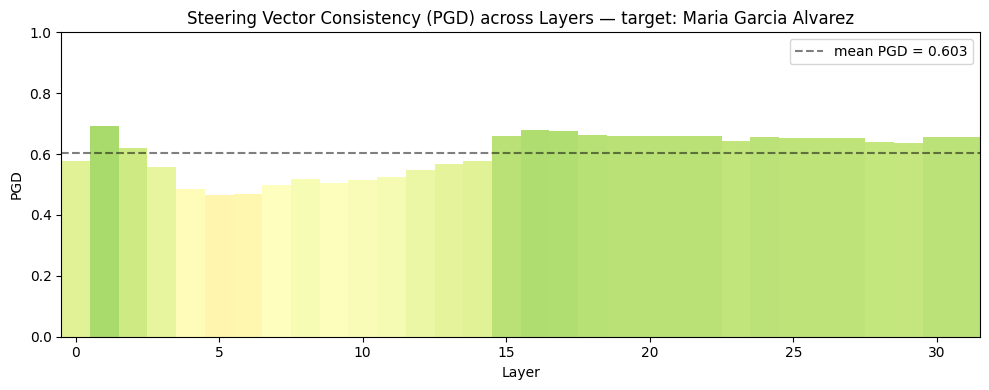

Most consistent layer: 1 (PGD = 0.6914)
Currently used layer 12: PGD = 0.5469


In [6]:
# --- Phase Gradient Directionality (PGD) of steering vectors ---
# PGD(layer) = ||mean(d_i)|| / mean(||d_i||)
# where d_i = bad_acts[i] - good_acts[i] is the per-sample steering vector.
# PGD=1 → all samples agree on direction; PGD→0 → no consistent direction.

good_acts = t.load("store/llama3/good.pt")
bad_acts = t.load("store/llama3/bad.pt")

deltas = bad_acts - good_acts  # (n_samples, num_layers, 1, hidden_dim)
deltas = deltas[:, :, 0, :]   # (n_samples, num_layers, hidden_dim)

num_layers = deltas.shape[1]
pgd = t.zeros(num_layers)

for layer in range(num_layers):
    vecs = deltas[:, layer, :]                        # (n_samples, hidden_dim)
    mag_of_mean = vecs.mean(dim=0).norm()             # ||mean(d_i)||
    mean_of_mag = vecs.norm(dim=1).mean()             # mean(||d_i||)
    pgd[layer] = mag_of_mean / mean_of_mag

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))
layers = range(num_layers)
colors = plt.cm.RdYlGn(pgd.numpy())

ax.bar(layers, pgd.numpy(), color=colors, edgecolor="none", width=1.0)
ax.set_xlabel("Layer")
ax.set_ylabel("PGD")
ax.set_title(f"Steering Vector Consistency (PGD) across Layers — target: {first_author}")
ax.set_xlim(-0.5, num_layers - 0.5)
ax.set_ylim(0, 1)
ax.axhline(y=pgd.mean(), color="black", linestyle="--", alpha=0.5, label=f"mean PGD = {pgd.mean():.3f}")
ax.legend()
plt.tight_layout()
plt.show()

best_layer = pgd.argmax().item()
print(f"Most consistent layer: {best_layer} (PGD = {pgd[best_layer]:.4f})")
print(f"Currently used layer 12: PGD = {pgd[12]:.4f}")

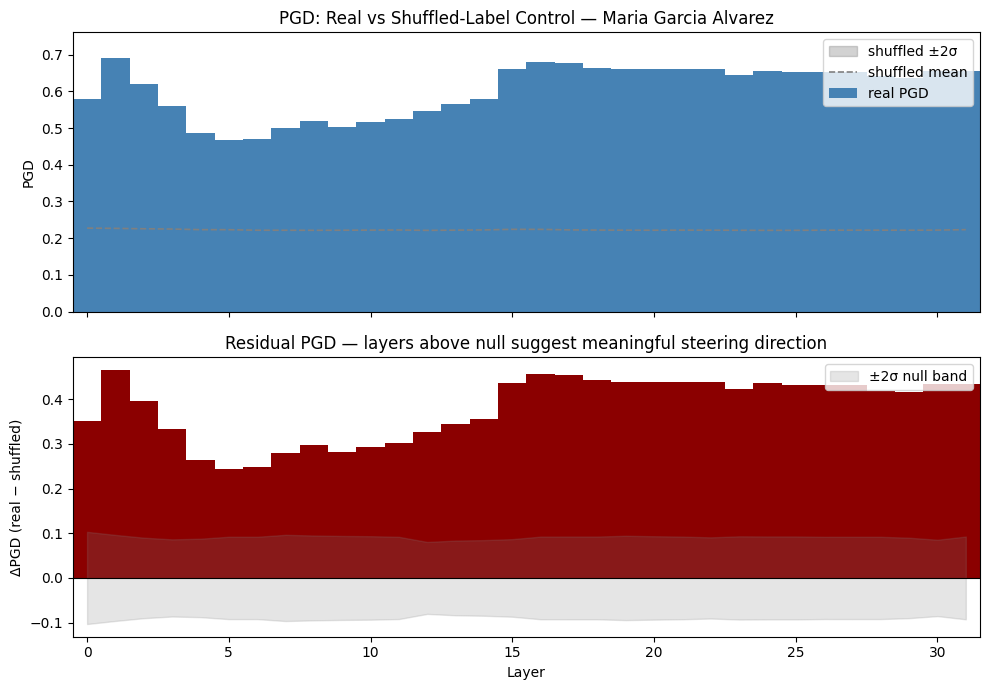

Top 5 layers by residual PGD:
  Layer 1: PGD=0.6914, shuffled=0.2267, Δ=0.4647, z=9.7σ
  Layer 16: PGD=0.6797, shuffled=0.2240, Δ=0.4557, z=9.9σ
  Layer 17: PGD=0.6758, shuffled=0.2226, Δ=0.4532, z=9.8σ
  Layer 18: PGD=0.6641, shuffled=0.2220, Δ=0.4420, z=9.6σ
  Layer 20: PGD=0.6602, shuffled=0.2216, Δ=0.4385, z=9.4σ


In [11]:
# --- PGD with shuffled-label control ---
import numpy as np

n_shuffles = 200
all_acts = t.cat([good_acts[:, :, 0, :], bad_acts[:, :, 0, :]], dim=0)  # (2N, layers, hidden)
n = good_acts.shape[0]

pgd_shuffled = np.zeros((n_shuffles, num_layers))

for s in range(n_shuffles):
    perm = np.random.permutation(2 * n)
    shuf_good = all_acts[perm[:n]]
    shuf_bad = all_acts[perm[n:]]
    shuf_deltas = shuf_bad - shuf_good
    for layer in range(num_layers):
        vecs = shuf_deltas[:, layer, :].float()
        mag_of_mean = vecs.mean(dim=0).norm().item()
        mean_of_mag = vecs.norm(dim=1).mean().item()
        pgd_shuffled[s, layer] = mag_of_mean / mean_of_mag

pgd_shuf_mean = pgd_shuffled.mean(axis=0)
pgd_shuf_std = pgd_shuffled.std(axis=0)
pgd_np = pgd.numpy()

# --- Plot 1: Real PGD vs shuffled control ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

x = np.arange(num_layers)
ax1.bar(x, pgd_np, color="steelblue", edgecolor="none", width=1.0, label="real PGD", zorder=2)
ax1.fill_between(x, pgd_shuf_mean - 2 * pgd_shuf_std, pgd_shuf_mean + 2 * pgd_shuf_std,
                 color="gray", alpha=0.35, label="shuffled ±2σ", zorder=1)
ax1.plot(x, pgd_shuf_mean, color="gray", ls="--", lw=1.2, label="shuffled mean", zorder=3)
ax1.set_ylabel("PGD")
ax1.set_title(f"PGD: Real vs Shuffled-Label Control — {first_author}")
ax1.set_ylim(0, max(pgd_np.max(), (pgd_shuf_mean + 2 * pgd_shuf_std).max()) * 1.1)
ax1.legend(loc="upper right")

# --- Plot 2: Residual (real - shuffled mean), colored by significance ---
residual = pgd_np - pgd_shuf_mean
z_score = (pgd_np - pgd_shuf_mean) / pgd_shuf_std
significant = np.abs(z_score) > 2
bar_colors = np.where(significant, "darkred", "lightgray")

ax2.bar(x, residual, color=bar_colors, edgecolor="none", width=1.0)
ax2.axhline(0, color="black", lw=0.8)
ax2.fill_between(x, -2 * pgd_shuf_std, 2 * pgd_shuf_std, color="gray", alpha=0.2, label="±2σ null band")
ax2.set_xlabel("Layer")
ax2.set_ylabel("ΔPGD (real − shuffled)")
ax2.set_title("Residual PGD — layers above null suggest meaningful steering direction")
ax2.legend(loc="upper right")
ax2.set_xlim(-0.5, num_layers - 0.5)

plt.tight_layout()
plt.show()

top_residual = np.argsort(residual)[::-1][:5]
print("Top 5 layers by residual PGD:")
for l in top_residual:
    print(f"  Layer {l}: PGD={pgd_np[l]:.4f}, shuffled={pgd_shuf_mean[l]:.4f}, "
          f"Δ={residual[l]:.4f}, z={z_score[l]:.1f}σ")

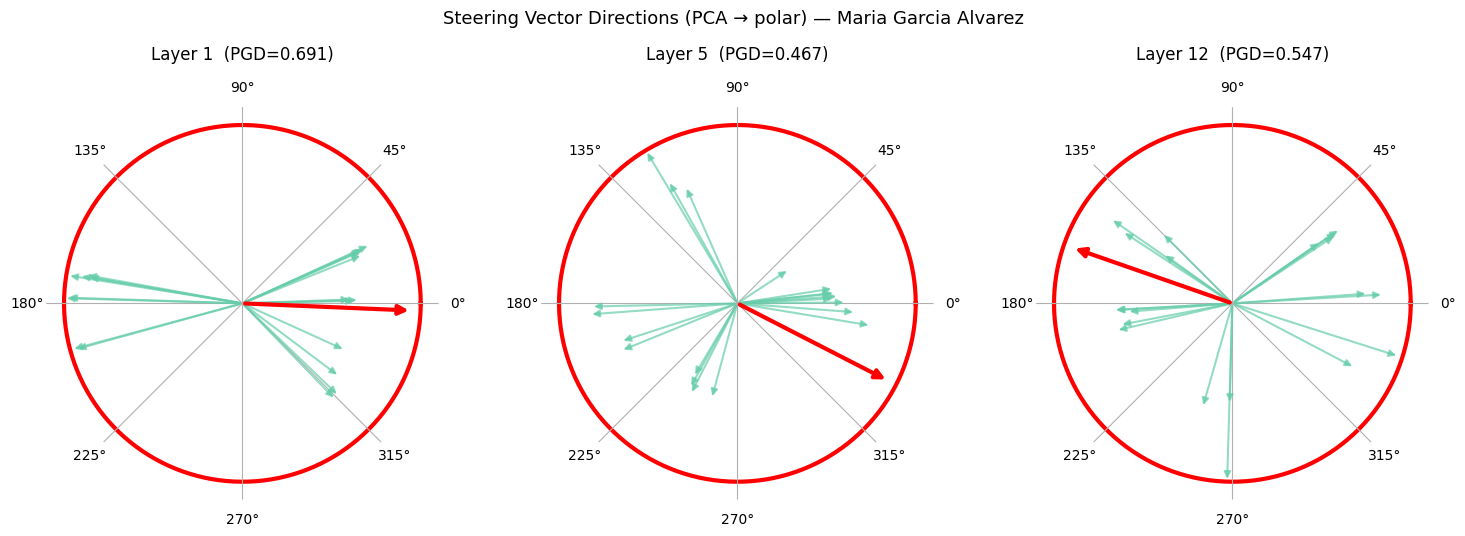

In [9]:
# --- Circular distribution of steering vectors (PCA → polar) ---
import numpy as np
from sklearn.decomposition import PCA

best_l = pgd.argmax().item()
worst_l = pgd.argmin().item()
show_layers = sorted(set([worst_l, 12, best_l]))

fig, axes = plt.subplots(1, len(show_layers), figsize=(5 * len(show_layers), 5),
                         subplot_kw={"projection": "polar"})
if len(show_layers) == 1:
    axes = [axes]

for ax, layer in zip(axes, show_layers):
    vecs = deltas[:, layer, :].float().numpy()

    pca = PCA(n_components=2)
    proj = pca.fit_transform(vecs)
    angles = np.arctan2(proj[:, 1], proj[:, 0])
    mags = np.linalg.norm(proj, axis=1)
    mags = mags / mags.max()  # normalize to [0, 1] for plotting

    # Outer red circle
    theta_circle = np.linspace(0, 2 * np.pi, 300)
    ax.plot(theta_circle, np.ones_like(theta_circle), color="red", lw=3, zorder=0)

    # Teal arrows from center — length proportional to magnitude
    for ang, mag in zip(angles, mags):
        ax.annotate("", xy=(ang, mag), xytext=(0, 0),
                     arrowprops=dict(arrowstyle="-|>", color="mediumaquamarine",
                                     alpha=0.7, lw=1.5, mutation_scale=10))

    # Mean direction – bold red arrow
    mean_ang = np.arctan2(np.sin(angles).mean(), np.cos(angles).mean())
    ax.annotate("", xy=(mean_ang, 0.95), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color="red", lw=3, mutation_scale=14))

    ax.set_ylim(0, 1.1)
    ax.set_yticks([])
    ax.set_rlabel_position(0)
    ax.spines["polar"].set_visible(False)
    ax.set_title(f"Layer {layer}  (PGD={pgd[layer]:.3f})", pad=15, fontsize=12)

plt.suptitle(f"Steering Vector Directions (PCA → polar) — {first_author}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

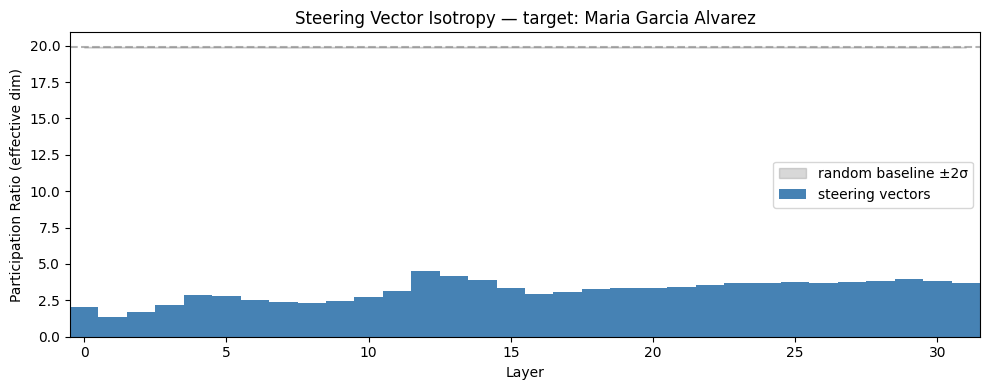

Max possible PR (n_samples): 20
Mean real PR: 3.17  |  Mean random PR: 19.90
Layer 12 PR: 4.51  |  Best PGD layer 1 PR: 1.36


In [10]:
# --- Participation Ratio: effective dimensionality of steering vectors ---
# PR = (Σλ_i)² / Σλ_i²  where λ_i are PCA eigenvalues
# Low PR → vectors live on a low-dim manifold (structured)
# High PR → isotropic / random in full space

import numpy as np

n_samples, _, hidden_dim = deltas.shape[0], deltas.shape[1], deltas.shape[2]
n_random_trials = 50

pr_real = np.zeros(num_layers)
pr_random_mean = np.zeros(num_layers)
pr_random_std = np.zeros(num_layers)

for layer in range(num_layers):
    vecs = deltas[:, layer, :].float().numpy()

    # Real PR
    cov = np.cov(vecs, rowvar=True)  # (n_samples, n_samples)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.maximum(eigvals, 0)
    pr_real[layer] = eigvals.sum() ** 2 / (eigvals ** 2).sum()

    # Random baseline: same shape, Gaussian
    pr_trials = []
    for _ in range(n_random_trials):
        rand_vecs = np.random.randn(n_samples, hidden_dim).astype(np.float32)
        cov_r = np.cov(rand_vecs, rowvar=True)
        ev_r = np.linalg.eigvalsh(cov_r)
        ev_r = np.maximum(ev_r, 0)
        pr_trials.append(ev_r.sum() ** 2 / (ev_r ** 2).sum())
    pr_random_mean[layer] = np.mean(pr_trials)
    pr_random_std[layer] = np.std(pr_trials)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(num_layers)

ax.bar(x, pr_real, color="steelblue", edgecolor="none", width=1.0, label="steering vectors")
ax.fill_between(x, pr_random_mean - 2 * pr_random_std, pr_random_mean + 2 * pr_random_std,
                color="gray", alpha=0.3, label="random baseline ±2σ")
ax.axhline(pr_random_mean.mean(), color="gray", ls="--", alpha=0.6)

ax.set_xlabel("Layer")
ax.set_ylabel("Participation Ratio (effective dim)")
ax.set_title(f"Steering Vector Isotropy — target: {first_author}")
ax.set_xlim(-0.5, num_layers - 0.5)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Max possible PR (n_samples): {n_samples}")
print(f"Mean real PR: {pr_real.mean():.2f}  |  Mean random PR: {pr_random_mean.mean():.2f}")
print(f"Layer 12 PR: {pr_real[12]:.2f}  |  Best PGD layer {best_layer} PR: {pr_real[best_layer]:.2f}")